[5] Visualizing Average Anomaly Signal (Regression Baseline)...


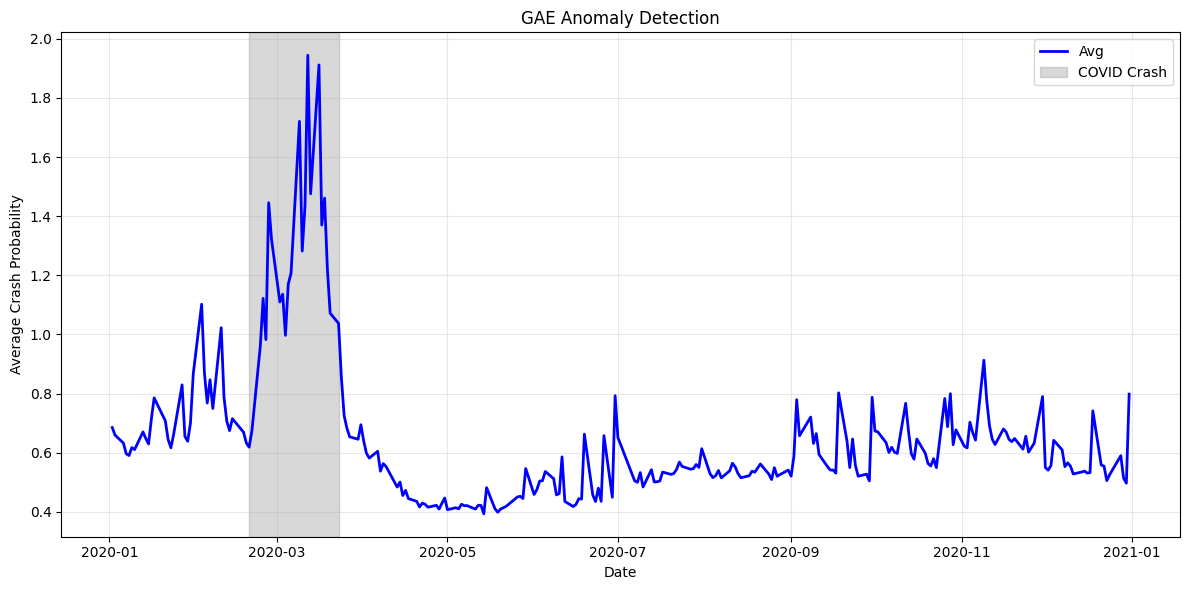

FW= 10 CT= -0.10 AUC=0.593 Lift=2.30Baseline=0.03Precision=0.08
FW= 10 CT= -0.15 AUC=0.705 Lift=3.90Baseline=0.01Precision=0.05
FW= 10 CT= -0.20 AUC=0.788 Lift=5.20Baseline=0.01Precision=0.03
FW= 10 CT= -0.30 AUC=0.848 Lift=5.92Baseline=0.00Precision=0.01
FW= 22 CT= -0.10 AUC=0.553 Lift=1.60Baseline=0.07Precision=0.11
FW= 22 CT= -0.15 AUC=0.611 Lift=2.33Baseline=0.03Precision=0.06
FW= 22 CT= -0.20 AUC=0.666 Lift=3.11Baseline=0.01Precision=0.04
FW= 22 CT= -0.30 AUC=0.731 Lift=4.06Baseline=0.00Precision=0.02

  Spectral range comparison  [2020-03-12]
  Statistic                        A+         A-     Δ (A- − A+)
  --------------------------------------------------------------
  lambda_max                   1.6222     2.0000         +0.3778
  lambda_median                1.0259     1.0000         -0.0259
  frac > 1.50                  0.0020     0.0060         +0.0040
  frac > 1.75                  0.0000     0.0040         +0.0040


  Spectral range comparison  [2019-06-15]
  Statistic

In [1]:
from gae_grasped import compare_spectral_ranges
import pandas as pd
import nbformat, types

# Load notebook functions (same trick as test_wavelet_date.py)
def load_nb(path):
    import nbformat, types
    nb = nbformat.read(path, as_version=4)
    mod = types.ModuleType("nb")
    for cell in nb.cells:
        if cell.cell_type == "code" and cell.source.strip():
            try:
                exec(compile(cell.source, "<cell>", "exec"), mod.__dict__)
            except:
                pass
    return mod

nb = load_nb("GAE_working_BEST23Apr_spectral.ipynb")

returns = pd.read_excel("SPX_sectors_data.xlsx", header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns = returns.pct_change().dropna(how="all").ffill().bfill()

for date in ["2020-03-12", "2019-06-15", "2020-03-16"]:
    t = pd.to_datetime(date)
    active = nb.get_active_stocks(returns, t, lookback_days=32, min_obs=21)
    corr, active = nb.correlation_matrix(returns, t, K=21, active=active)
    A_pos, A_neg = nb.create_adjacency_from_correlation(corr)
    compare_spectral_ranges(A_pos, A_neg, label=date)